    RID         Age  Income Student CreditRating buys_comp
0     1       Youth    High      No         Fair        No
1     2       Youth    High      No    Excellent        No
2     3  MiddleAged    High      No         Fair       Yes
3     4      Senior  Medium      No         Fair       Yes
4     5      Senior     Low     Yes         Fair       Yes
5     6      Senior     Low     Yes    Excellent        No
6     7  MiddleAged     Low     Yes    Excellent       Yes
7     8       Youth  Medium      No         Fair        No
8     9       Youth     Low     Yes         Fair       Yes
9    10      Senior  Medium     Yes         Fair       Yes
10   11       Youth  Medium     Yes    Excellent       Yes
11   12  MiddleAged  Medium      No    Excellent       Yes
12   13  MiddleAged    High     Yes         Fair       Yes
13   14      Senior  Medium      No    Excellent        No
[1 1 0]
Accuracy: 1.0


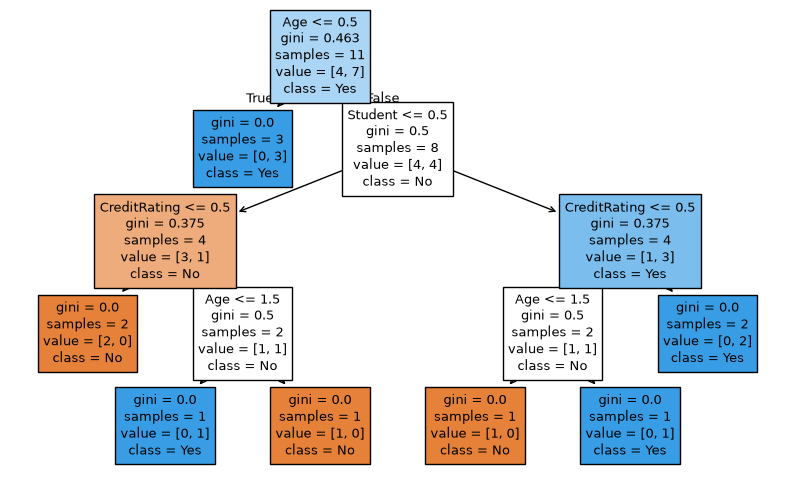

In [1]:
import pandas as pd

df = pd.read_csv("/Users/keerti/Desktop/ML/dataset.csv")
print(df)

df = df.drop("RID", axis=1)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("buys_comp", axis=1)
y = df["buys_comp"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True
)

plt.show()